# Cluster HFpEF Visualization

In [19]:
%reload_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import seaborn as sn

from IPython.display import display

from preproc import get_hfpef_200, convert2np

In [20]:
no_clusters = 8
lbl_colname= ['Death', 'CV death', 'Major cardiac events']

## Get Data

In [21]:
data_df = get_hfpef_200()

In [23]:
data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 49 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   200 non-null    int64  
 1   Sex                   200 non-null    int64  
 2   Cr                    200 non-null    float64
 3   GFR                   200 non-null    float64
 4   CKD stage             200 non-null    int64  
 5   smoke                 200 non-null    float64
 6   BMI                   200 non-null    float64
 7   BSA                   200 non-null    float64
 8   DM                    200 non-null    int64  
 9   Insulin               200 non-null    int64  
 10  AF                    200 non-null    int64  
 11  SBP                   200 non-null    int64  
 12  DBP                   200 non-null    int64  
 13  MAP                   200 non-null    float64
 14  PP                    200 non-null    int64  
 15  1/2SBP                2

In [24]:
data_df.describe()

,Age,Sex,Cr,GFR,CKD stage,smoke,BMI,BSA,DM,Insulin,...,E/A,Mitral E/e',TR Vmax,RWT,LV mass index,LVH,LAVI,LACI,LA diameter,LVEF
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,...,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,72.045000,1.680000,1.711100,52.293250,2.810000,0.105000,26.738830,1.632980,0.560000,0.215000,...,0.741571,17.300650,1.890100,0.648305,115.640950,2.640000,31.987000,3.211636,3.670264,61.434500
std,11.404529,0.467647,1.534721,25.188572,1.043718,0.307323,6.636857,0.228277,0.497633,0.411853,...,0.606755,8.602117,1.443655,0.388423,52.778994,1.896943,26.285226,3.988946,1.446008,8.420635
min,31.000000,1.000000,0.550000,2.000000,1.000000,0.000000,15.400000,1.120000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,65.000000,1.000000,0.887500,34.750000,2.000000,0.000000,22.200000,1.485000,0.000000,0.000000,...,0.500000,11.600000,0.000000,0.400000,86.725000,1.000000,0.000000,0.000000,3.500000,56.000000
50%,74.000000,2.000000,1.140000,54.000000,3.000000,0.000000,26.300000,1.600000,1.000000,0.000000,...,0.700000,16.300000,2.460000,0.555000,113.150000,2.500000,32.600000,2.479869,4.000000,61.000000
75%,80.000000,2.000000,1.792500,70.250000,3.000000,0.000000,29.925000,1.800000,1.000000,0.000000,...,1.000000,22.100000,3.002500,0.865000,141.305000,4.000000,48.425000,5.111374,4.400000,66.000000
max,97.000000,2.000000,10.000000,108.000000,5.000000,1.000000,55.900000,2.300000,1.000000,1.000000,...,4.100000,42.200000,4.550000,2.300000,356.600000,7.000000,140.800000,23.665480,6.200000,82.900000


## 1. All Features

In [25]:
from sklearn.cluster import SpectralClustering, KMeans
from sklearn.mixture import GaussianMixture

from sklearn.pipeline import make_pipeline

from utils import get_score, score_columns, plot_data

import matplotlib.pyplot as plt
%matplotlib inline

In [26]:
X, y, feature_list = convert2np(data_df, lbl_colname)

In [27]:
def get_km_pred(k, X):
    km = KMeans(n_clusters=k, random_state=0)
    return km.fit_predict(X)

def get_sc_pred(k, X):
    sc = SpectralClustering(n_clusters=k, eigen_solver='arpack', affinity="nearest_neighbors", random_state=0)
    return sc.fit_predict(X)

def get_gm_pred(k, X):
    gm = GaussianMixture(n_components=k, random_state=0, init_params='kmeans').fit(X)
    return gm.predict(X)

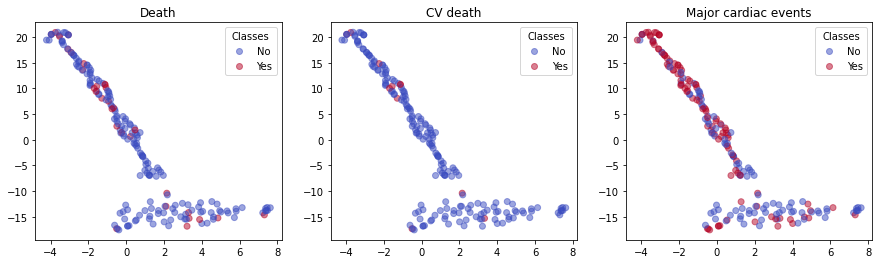

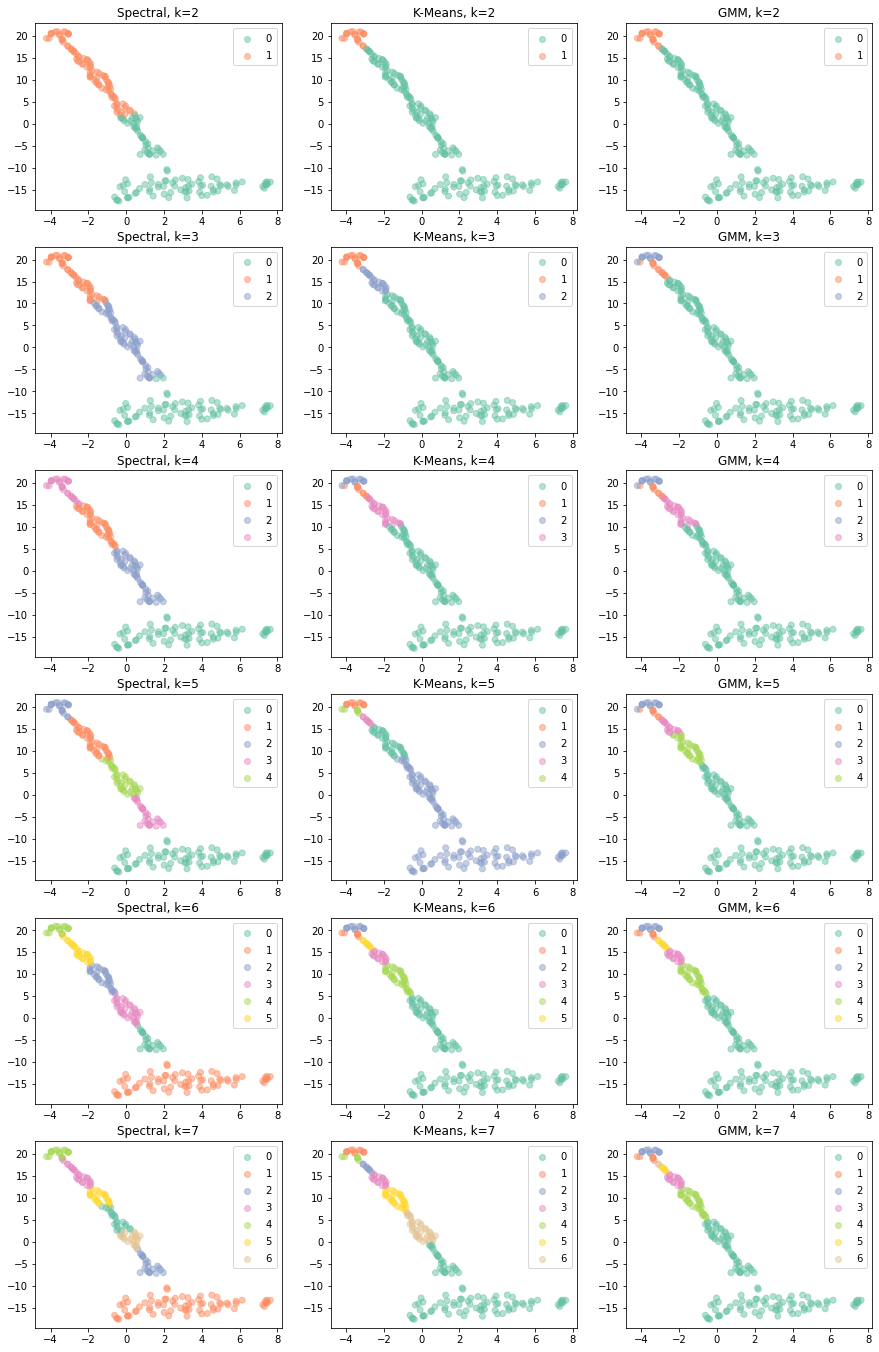

In [28]:
plot_data(X, y, no_clusters, {"Spectral":get_sc_pred, "K-Means":get_km_pred, "GMM":get_gm_pred}, lbl_colname)

## 2. Selected Feature

In [29]:
X, y, feature_list = convert2np(data_df, lbl_colname, selected_feat=True)

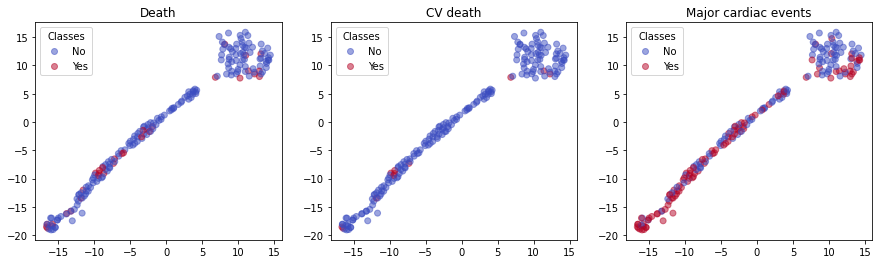

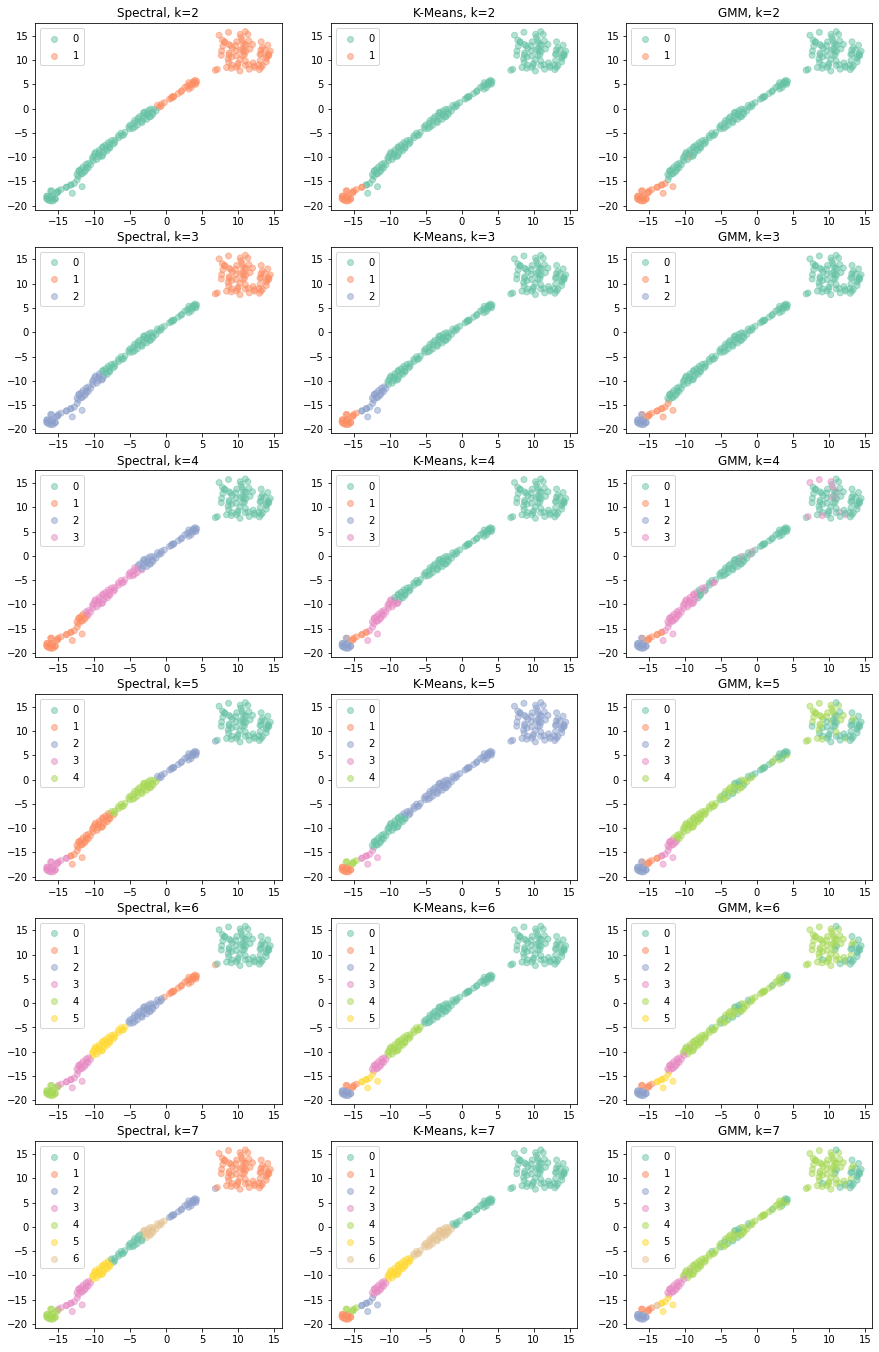

In [30]:
plot_data(X, y, no_clusters, {"Spectral":get_sc_pred, "K-Means":get_km_pred, "GMM":get_gm_pred}, lbl_colname)

## Get Cleaned Data

In [31]:
data_df_nomiss = get_hfpef_200(nomiss=True)

In [33]:
data_df_nomiss.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 70 entries, 1 to 199
Data columns (total 49 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   70 non-null     int64  
 1   Sex                   70 non-null     int64  
 2   Cr                    70 non-null     float64
 3   GFR                   70 non-null     float64
 4   CKD stage             70 non-null     int64  
 5   smoke                 70 non-null     float64
 6   BMI                   70 non-null     float64
 7   BSA                   70 non-null     float64
 8   DM                    70 non-null     int64  
 9   Insulin               70 non-null     int64  
 10  AF                    70 non-null     int64  
 11  SBP                   70 non-null     int64  
 12  DBP                   70 non-null     int64  
 13  MAP                   70 non-null     float64
 14  PP                    70 non-null     int64  
 15  1/2SBP                70

In [34]:
data_df_nomiss.describe()

,Age,Sex,Cr,GFR,CKD stage,smoke,BMI,BSA,DM,Insulin,...,E/A,Mitral E/e',TR Vmax,RWT,LV mass index,LVH,LAVI,LACI,LA diameter,LVEF
count,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,...,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000
mean,72.014286,1.671429,1.704714,54.063429,2.728571,0.071429,26.173412,1.616043,0.628571,0.242857,...,0.977714,19.724143,1.961571,0.692429,121.555714,2.914286,40.508571,5.888278,4.000261,62.268571
std,11.643861,0.473085,1.557876,27.682150,1.141083,0.259399,6.245556,0.197336,0.486675,0.431906,...,0.482007,9.097155,1.387045,0.393100,46.882241,1.847386,18.354194,4.187923,0.672115,7.270798
min,31.000000,1.000000,0.640000,2.000000,1.000000,0.000000,15.400000,1.200000,0.000000,0.000000,...,0.400000,4.290000,0.000000,0.230000,53.800000,0.000000,12.500000,1.695652,2.100000,50.000000
25%,65.000000,1.000000,0.870000,32.000000,2.000000,0.000000,21.950000,1.455000,0.000000,0.000000,...,0.700000,13.050000,0.000000,0.420750,90.200000,1.000000,27.525000,3.142256,3.600000,57.475000
50%,74.500000,2.000000,1.120000,57.500000,3.000000,0.000000,25.450000,1.600000,1.000000,0.000000,...,0.900000,17.950000,2.440000,0.573500,113.450000,3.000000,36.900000,4.654273,4.000000,61.000000
75%,79.000000,2.000000,1.900000,76.500000,3.000000,0.000000,29.175000,1.775000,1.000000,0.000000,...,1.200000,23.500000,3.050000,0.900000,137.200000,4.000000,48.275000,6.919496,4.389250,67.000000
max,92.000000,2.000000,10.000000,108.000000,5.000000,1.000000,44.400000,2.000000,1.000000,1.000000,...,3.200000,42.200000,4.550000,2.300000,356.600000,7.000000,107.700000,23.665480,6.000000,78.200000


## 3. Cleaned Data

In [35]:
X, y, feature_list = convert2np(data_df_nomiss, lbl_colname, selected_feat=True)

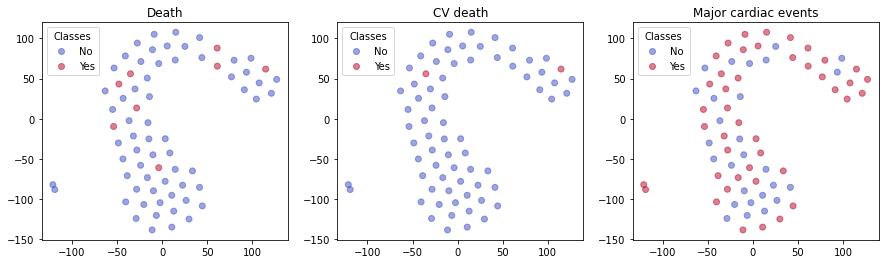

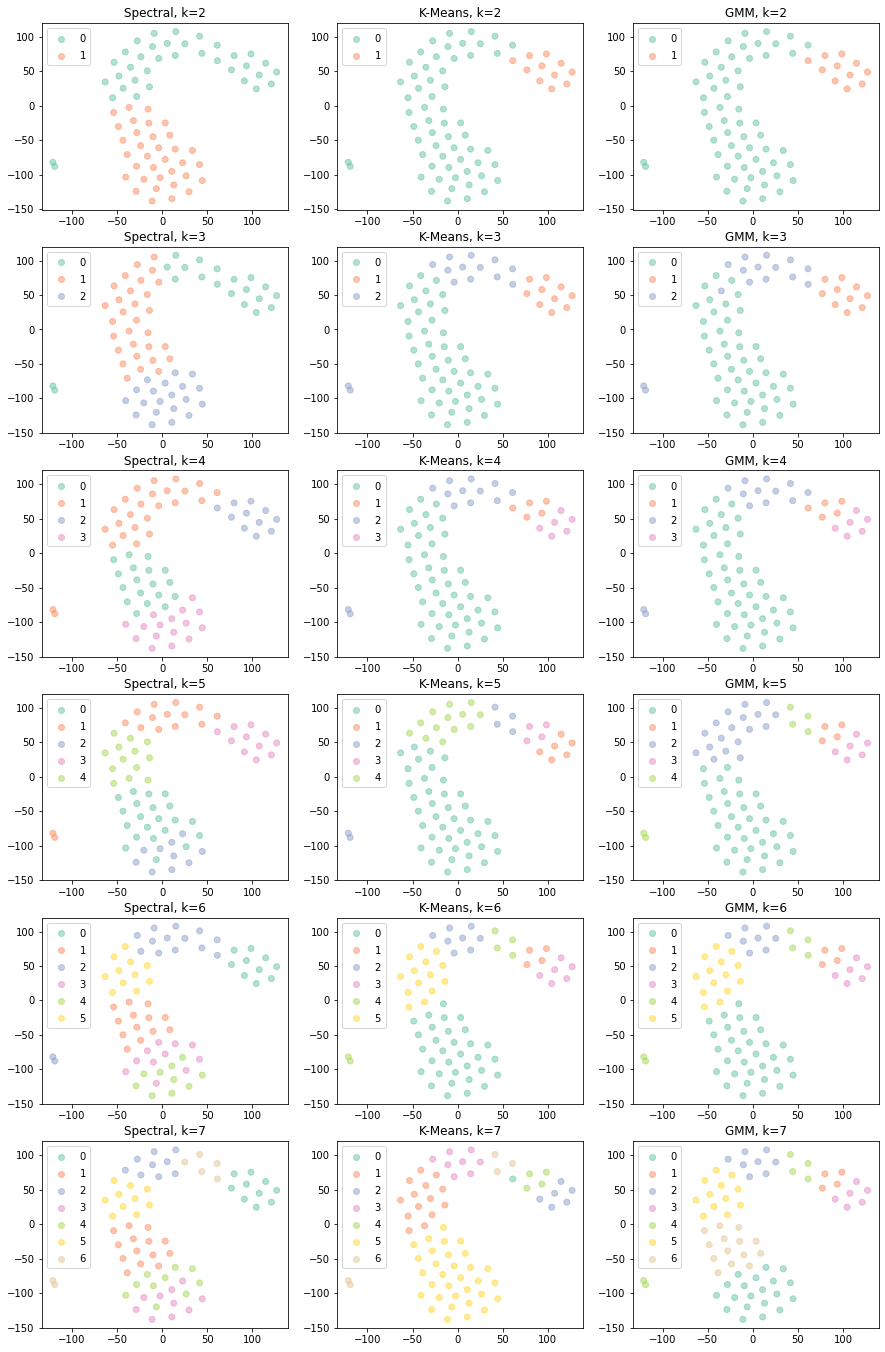

In [36]:
plot_data(X, y, no_clusters, {"Spectral":get_sc_pred, "K-Means":get_km_pred, "GMM":get_gm_pred}, lbl_colname)